# Preparación

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def imshow(title="example", img = None, cmap=None):
    plt.figure(figsize=(6,6))

    if len(img.shape) == 3:
        img_mostrar = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_mostrar = img
        if cmap==None:
            cmap="gray"

    plt.imshow(img_mostrar, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


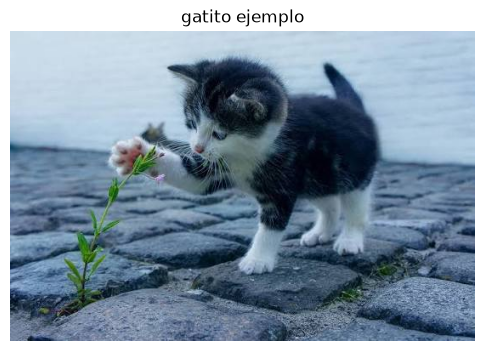

In [3]:
image_example = cv2.imread("gatito.jpeg")

imshow(title="gatito ejemplo", img=image_example)

# Dibujos y anotaciones

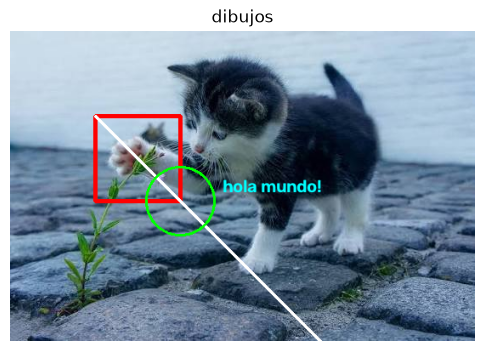

In [10]:
img_draw = image_example.copy()

cv2.rectangle(img_draw, pt1 = (100,100), pt2 = (200,200), color= (0, 0 , 255) , thickness=3)

cv2.line(img_draw, pt1=(100,100), pt2=(600,600), color=(255,255,255), thickness=2 )
cv2.circle(img_draw, center=(200,200), radius=40, color=(0,255,0), thickness=2)

text = "hola mundo!"

cv2.putText(img_draw, 
            text,
            org = (250,190), 
            fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
            fontScale=0.7, 
            color=(255,255,0),
            thickness=2)

imshow(title="dibujos", img=img_draw)

# Espacios de colores

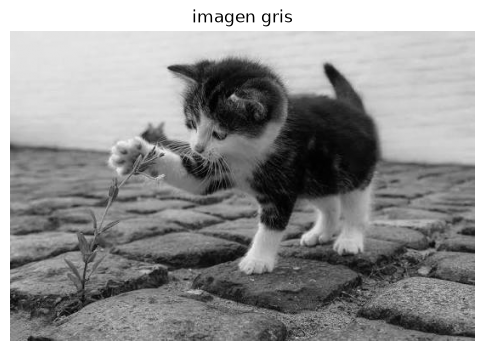

In [11]:
img_gray = cv2.cvtColor(image_example, cv2.COLOR_BGR2GRAY)
imshow(img=img_gray, title="imagen gris")

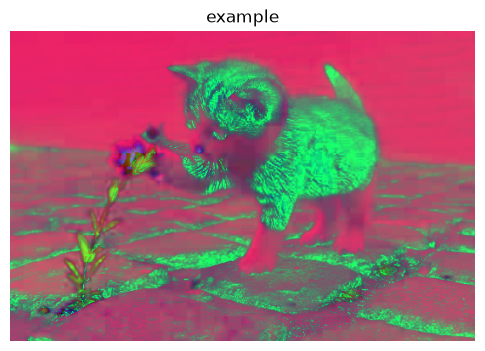

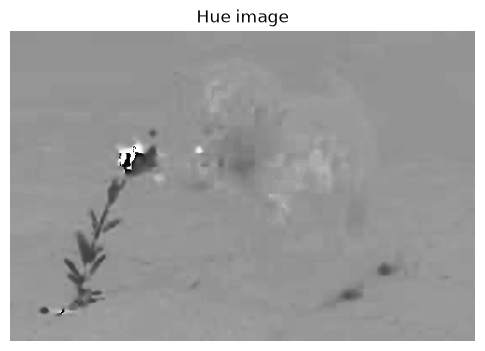

In [13]:
# Escala HSV

img_hsv = cv2.cvtColor(image_example, cv2.COLOR_BGR2HSV)
imshow(img=img_hsv)

H, S, V = cv2.split(img_hsv)
imshow(img=H, title="Hue image")



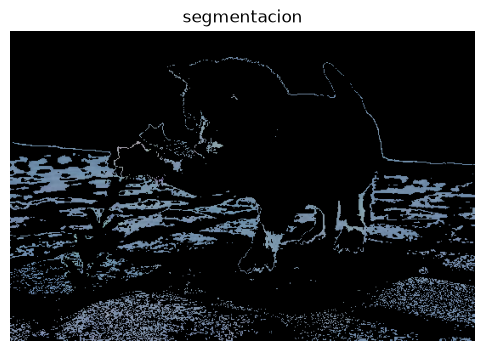

In [17]:
import numpy as np

bajo1 = np.array([0, 100, 100]); alto1 = np.array([10, 255, 255])
bajo2 = np.array([160, 100, 100]); alto2 = np.array([179, 255, 255])

mascara = cv2.inRange(image_example, bajo1, alto1) | cv2.inRange(image_example, bajo2, alto2)
resultado = cv2.bitwise_and(image_example, image_example, mask=mascara)

imshow(img=resultado, title="segmentacion")

Examinación de la imagen segmentada

In [19]:
print(resultado.shape)
print(resultado.mean())

(365, 547, 3)
16.72110557378144


# Reducción de ruido

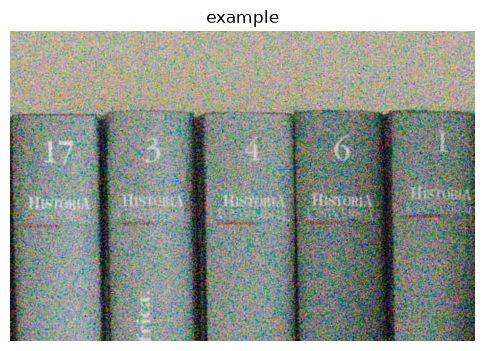

In [29]:
noise_img = cv2.imread("noise_image.jpg")
imshow(img=noise_img)

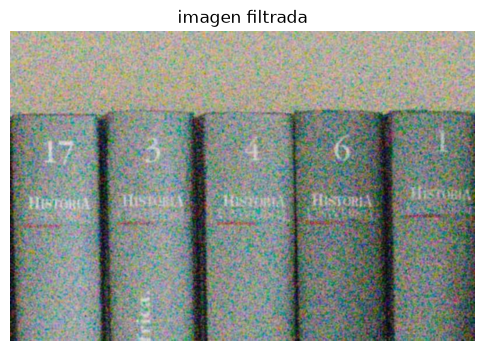

In [25]:
# Filtrado Gaussiano
img_noise = noise_img.copy()

filtered_img = cv2.GaussianBlur(img_noise, (3,3), sigmaX = 0)
imshow(img=filtered_img, title="imagen filtrada")

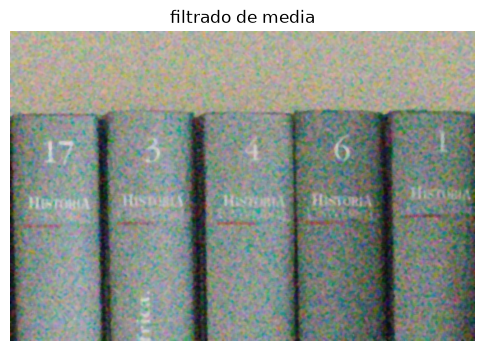

In [31]:
# filtro de mediana
filtered_med = cv2.medianBlur(noise_img, 5)
imshow(img=filtered_med, title="filtrado de media")

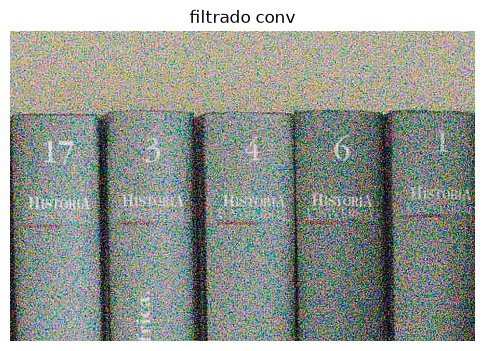

In [34]:
#filtrado conv
kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0],
])

filtered_conv = cv2.filter2D(noise_img, ddepth=-1, kernel=kernel)

imshow(img=filtered_conv, title="filtrado conv")